# Statistical Inference Tutorial

Trong lab này là một hướng dẫn cơ bản đến một số khái niệm quan trọng trong thống kê và suy luận thống kê. Tôi cố gắng trình bày các khái niệm một cách thú vị và tương tác, và tôi khuyến khích bạn tương tác với mã nguồn để hiểu rõ hơn về các khái niệm này.






## Nội dung chính

- [Biến rời rạc và Biến liên tục (Discrete and Continuous Variables)](#2)
  - Hàm Phân phối xác suất (PMF - Probability Mass Function)
  - Hàm Mật độ xác suất (PDF - Probability Density Function)
  - Hàm Phân phối tích luỹ (CDF - Cumulative Distribution Function)
- [Distributions](#3)
  - Phân phối Đồng đều (Uniform Distribution)
  - Phân phối Chuẩn (Normal Distribution)
  - Phân phối Nhị thức (Binomial Distribution)
  - Phân phối Poisson (Poisson Distribution)
  - Phân phối Log-normal (Log-normal Distribution)
- [Phương pháp Lấy mẫu (Sampling Methods)](#6)
- [Covariance](#7)
- [Tương quan (Correlation)](#8)
- [Kiểm định giả thuyết (Hypothesis Testing)](#11)
  - p-value
  - q-q plot
- [Sources](#16)

## Preparation <a id="1"></a>

Import các thư viện cần thiết trong lab này

In [1]:
# Dependencies
# Standard Dependencies
import os
import numpy as np
import pandas as pd
from math import sqrt

# Visualization
from pylab import *
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from statistics import median
from scipy import signal
from scipy.special import factorial
import scipy.stats as stats
from scipy.stats import sem, binom, lognorm, poisson, bernoulli, spearmanr
from scipy.fftpack import fft, fftshift

# Read in csv of Toy Dataset
# We will use this dataset throughout the tutorial
df = pd.read_csv('L12_datasets/toy_dataset.csv')

## Discrete and Continuous Variables <a id="2"></a>

Biến rời rạc (discrete variable) là một biến chỉ có thể nhận một số giá trị cố định. Nếu bạn có thể đếm được một tập hợp các mục, thì đó là một biến rời rạc. Một ví dụ về biến rời rạc là kết quả của một con xúc xắc. Nó chỉ có thể có một trong 6 kết quả khác nhau và do đó là biến rời rạc.


Biến liên tục (continuous variable) có thể nhận một số vô hạn giá trị. Một ví dụ về biến liên tục là chiều dài. Chiều dài có thể được đo đến bất kỳ độ chính xác nào và do đó là biến liên tục.

Trong thống kê, chúng ta biểu diễn phân phối của biến rời rạc bằng các PMF (Hàm Phân phối xác suất - Probability Mass Functions) và CDF (Hàm Phân phối tích luỹ - Cumulative Distribution Functions). Chúng ta biểu diễn phân phối của biến liên tục bằng các PDF (Hàm Mật độ xác suất - Probability Density Functions) và CDF. PMF và PDF giúp xác định xác suất của từng giá trị cụ thể, trong khi CDF cho biết xác suất tích luỹ của tất cả các giá trị đến một giá trị cụ thể.


PMF (Hàm Phân phối xác suất - Probability Mass Function) xác định xác suất của tất cả các giá trị có thể xảy ra x của biến ngẫu nhiên. Một PDF (Hàm Mật độ xác suất - Probability Density Function) cũng có chức năng tương tự nhưng dành cho các giá trị liên tục. PMF chỉ áp dụng cho biến rời rạc, trong khi PDF áp dụng cho biến liên tục. Cả hai định nghĩa xác định cách xác định xác suất cho các giá trị cụ thể của biến ngẫu nhiên.

CDF (Hàm Phân phối tích luỹ - Cumulative Distribution Function) biểu diễn xác suất rằng biến ngẫu nhiên X sẽ có một kết quả ít hơn hoặc bằng giá trị x. Tên CDF được sử dụng cho cả phân phối rời rạc và liên tục, và nó có cùng mục tiêu, đó là mô tả xác suất tích luỹ cho các giá trị của biến ngẫu nhiên.


Các hàm mô tả PMF (Hàm Phân phối xác suất), PDF (Hàm Mật độ xác suất) và CDF (Hàm Phân phối tích luỹ) có thể khá khó khăn khi mới tiếp xúc, nhưng các biểu đồ biểu thị chúng có vẻ rất trực quan và dễ hiểu. Visualizations giúp hiểu rõ hơn về cách xác suất và phân phối hoạt động trong thống kê, và chúng thường được sử dụng để trực quan hóa dữ liệu và kết quả phân tích.

### PMF (Hàm Phân phối xác suất - Probability Mass Function)

Ở đây, chúng ta trực quan hóa một PMF của phân phối nhị thức (binomial distribution). Bạn có thể thấy rằng các giá trị có thể là tất cả số nguyên. Ví dụ, không có giá trị nào nằm giữa 50 và 51.

PMF của phân phối nhị thức ở dạng hàm:

![](http://reliabilityace.com/formulas/binomial-pmf.png)

Trong đó:

- x là số lần thành công mong muốn trong N lần thử nghiệm.
- N là tổng số lần thử nghiệm.
- p là xác suất của một lần thử nghiệm thành công.


Tham khảo section 3 "[Distributions](#3)" về binomial distributions.

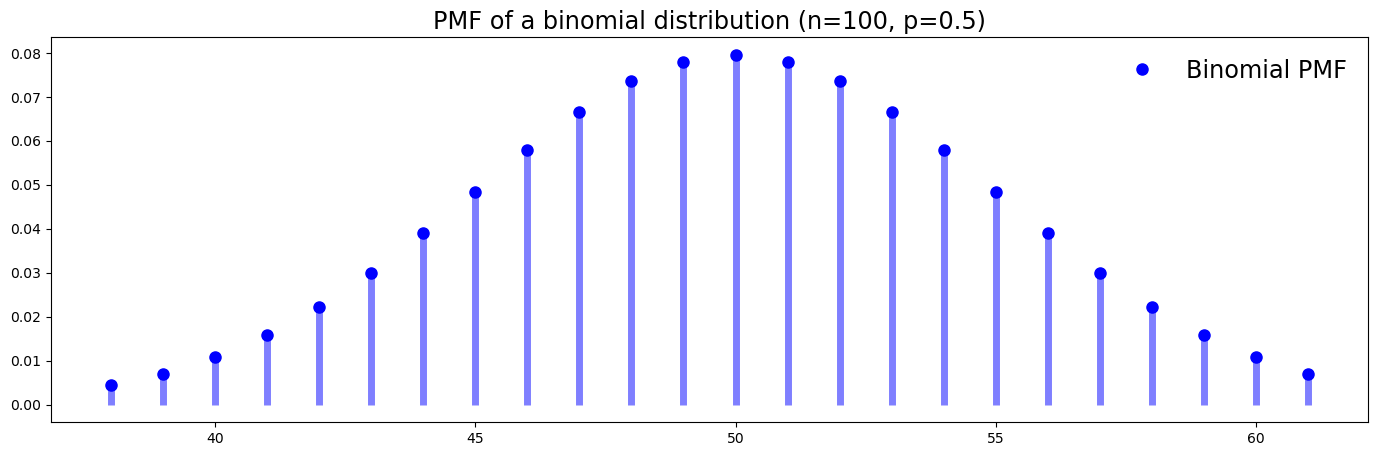

In [2]:
# PMF Visualization
n = 100
p = 0.5

fig, ax = plt.subplots(1, 1, figsize=(17,5))
x = np.arange(binom.ppf(0.01, n, p), binom.ppf(0.99, n, p))
ax.plot(x, binom.pmf(x, n, p), 'bo', ms=8, label='Binomial PMF')
ax.vlines(x, 0, binom.pmf(x, n, p), colors='b', lw=5, alpha=0.5)
rv = binom(n, p)
ax.legend(loc='best', frameon=False, fontsize='xx-large')
plt.title('PMF of a binomial distribution (n=100, p=0.5)', fontsize='xx-large')
plt.show()

### PDF (Hàm Mật độ xác suất - Probability Density Function)



PDF (Hàm Mật độ xác suất - Probability Density Function) tương tự như PMF, nhưng áp dụng cho biến ngẫu nhiên liên tục. Điều này có nghĩa rằng phân phối có một số vô hạn giá trị có thể xảy ra. Dưới đây, chúng ta trực quan hóa một phân phối chuẩn tiêu chuẩn với trung bình là 0 và độ lệch chuẩn là 1.

PDF của phân phối chuẩn tiêu chuẩn (standard normal distribution) có thể được biểu diễn bằng công thức sau:

![](https://www.mhnederlof.nl/images/normalpdf.jpg)

Trong đó:

- x là giá trị của biến ngẫu nhiên.
- μ là giá trị trung bình của phân phối.
- σ là độ lệch chuẩn của phân phối.
- π là số Pi (khoảng 3.14159).
- e là số Euler (khoảng 2.71828).

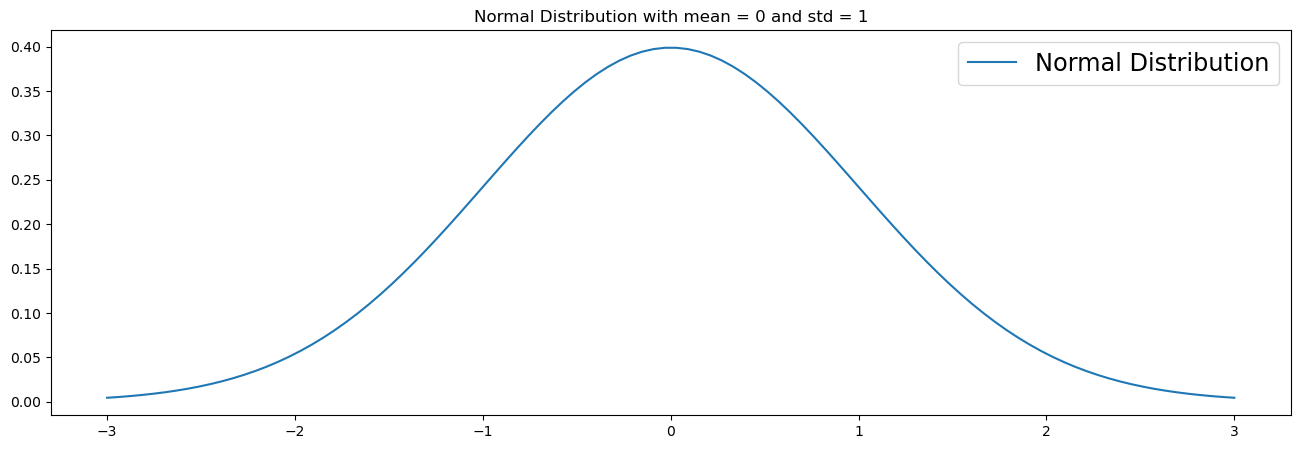

In [3]:
# Plot normal distribution
mu = 0
variance = 1
sigma = sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.figure(figsize=(16,5))
plt.plot(x, stats.norm.pdf(x, mu, sigma), label='Normal Distribution')
plt.title('Normal Distribution with mean = 0 and std = 1')
plt.legend(fontsize='xx-large')
plt.show()

### CDF (Hàm Phân phối tích luỹ - Cumulative Distribution Function)


CDF (Hàm Phân phối tích luỹ - Cumulative Distribution Function) ánh xạ xác suất rằng một biến ngẫu nhiên X sẽ có giá trị ít hơn hoặc bằng một giá trị x (P(X ≤ x)). CDF có thể là dạng rời rạc hoặc liên tục. Trong phần này, chúng ta trực quan hóa trường hợp liên tục. Bạn có thể thấy trên biểu đồ rằng CDF tích luỹ tất cả các xác suất và do đó giới hạn trong khoảng 0 ≤ x ≤ 1.

CDF của một phân phối chuẩn được biểu diễn bằng công thức sau:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/187f33664b79492eedf4406c66d67f9fe5f524ea)

*Note: erf means "[error function](https://en.wikipedia.org/wiki/Error_function)".*

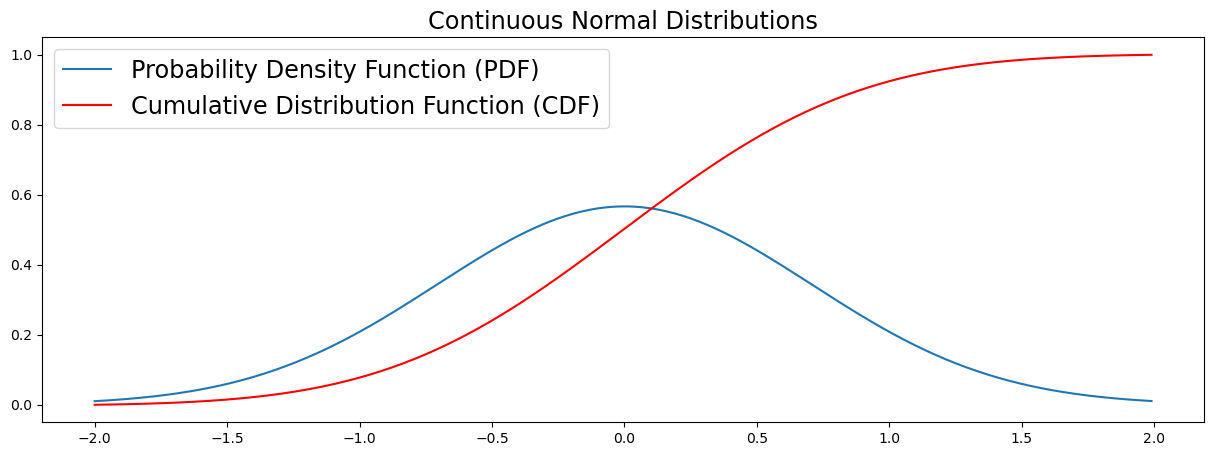

In [4]:
# Data
X  = np.arange(-2, 2, 0.01)
Y  = exp(-X ** 2)

# Normalize data
Y = Y / (0.01 * Y).sum()

# Plot the PDF and CDF
plt.figure(figsize=(15,5))
plt.title('Continuous Normal Distributions', fontsize='xx-large')
plot(X, Y, label='Probability Density Function (PDF)')
plot(X, np.cumsum(Y * 0.01), 'r', label='Cumulative Distribution Function (CDF)')
plt.legend(fontsize='xx-large')
plt.show()

## Distributions <a id="3"></a>

Một phân phối xác suất cho chúng ta biết điều gì đó về khả năng của mỗi giá trị của biến ngẫu nhiên.

Các hình ảnh minh họa trong phần này đều là về các phân phối rời rạc. Tuy nhiên, nhiều phân phối này cũng có thể là liên tục.

### Phân phối đều (Uniform Distribution)

Phân phối đều khá đơn giản. Mỗi giá trị có cùng khả năng xảy ra. Do đó, phân phối này bao gồm các giá trị ngẫu nhiên không có mẫu rõ ràng. Trong ví dụ này, chúng ta tạo ra các số thực ngẫu nhiên trong khoảng từ 0 đến 1..

Hàm mật độ xác suất (PDF) của Phân phối đều (Uniform Distribution):

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/648692e002b720347c6c981aeec2a8cca7f4182f)

Hàm Phân phối tích luỹ của Phân phối đều (Uniform Distribution):

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/eeeeb233753cfe775b24e3fec2f371ee8cdc63a6)

In [5]:
# Uniform distribution (between 0 and 1)
uniform_dist = np.random.random(1000)
uniform_df = pd.DataFrame({'value' : uniform_dist})
uniform_dist = pd.Series(uniform_dist)

Text(0.5, 1.0, 'Scatterplot of a Random/Uniform Distribution')

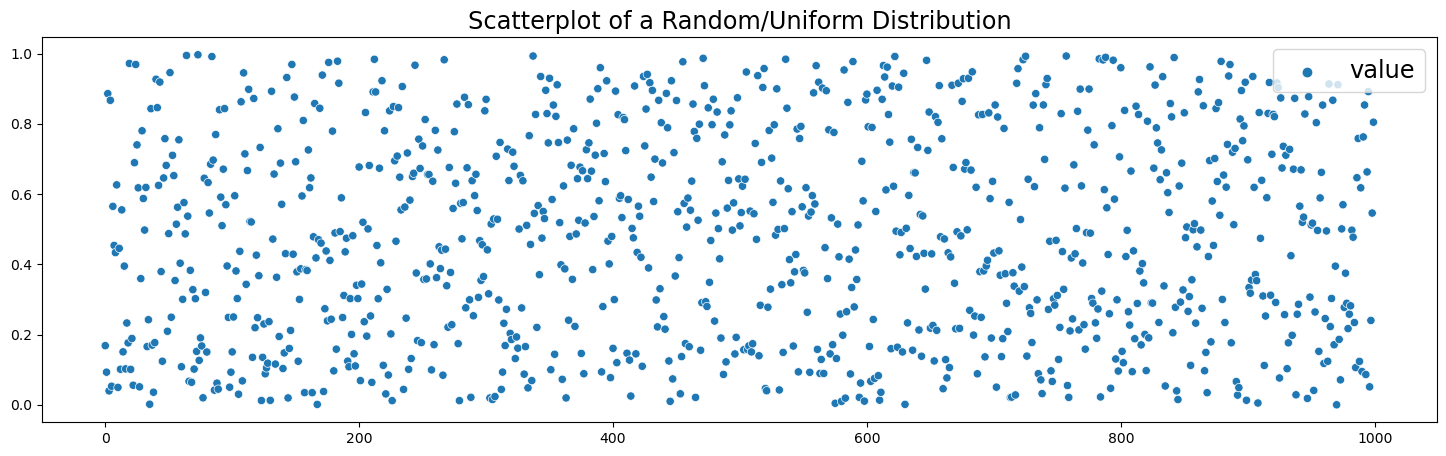

In [6]:
plt.figure(figsize=(18,5))
sns.scatterplot(data=uniform_df)
plt.legend(fontsize='xx-large')
plt.title('Scatterplot of a Random/Uniform Distribution', fontsize='xx-large')

/var/folders/px/dsgqr4nj72ng_369x1j527h80000gn/T/ipykernel_92269/3210366838.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(uniform_df)


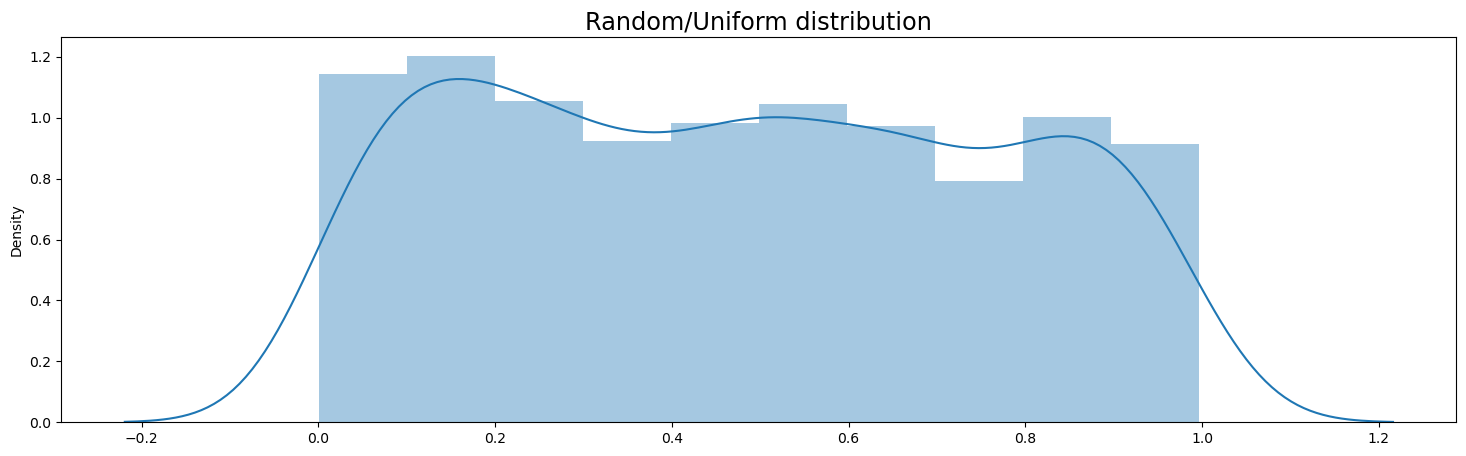

In [7]:
plt.figure(figsize=(18,5))
sns.distplot(uniform_df)
plt.title('Random/Uniform distribution', fontsize='xx-large')
plt.show()

### Normal Distribution

Phân phối chuẩn (còn được gọi là phân phối Gaussian hoặc phân phối hình chuông) rất phổ biến và tiện lợi. Điều này chủ yếu là do [Định lý Giới hạn Trung tâm (CLT)](https://en.wikipedia.org/wiki/Central_limit_theorem), mà nói rằng với một lượng lớn biến ngẫu nhiên độc lập (như việc tung đồng xu) phân phối có xu hướng tiến gần tới một phân phối chuẩn.

Hàm mật độ xác suất (PDF) của Phân phối chuẩn:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/2ce7e315b02666699e0cd8ea5fb1a3e0c287cd9d)

Hàm Phân phối tích luỹ của Phân phối chuẩn:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/187f33664b79492eedf4406c66d67f9fe5f524ea)


In [8]:
# Generate Normal Distribution
normal_dist = np.random.randn(10000)
normal_df = pd.DataFrame({'value' : normal_dist})
# Create a Pandas Series for easy sample function
normal_dist = pd.Series(normal_dist)

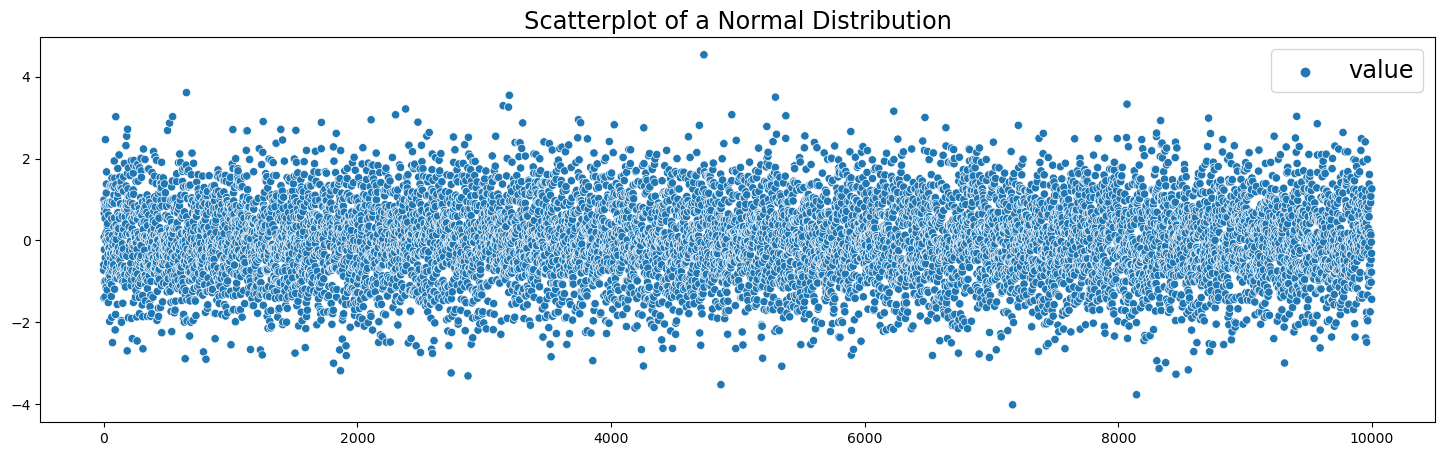

In [9]:
# Scatterplot
plt.figure(figsize=(18,5))
sns.scatterplot(data=normal_df)
plt.legend(fontsize='xx-large')
plt.title('Scatterplot of a Normal Distribution', fontsize='xx-large')
plt.show()

/var/folders/px/dsgqr4nj72ng_369x1j527h80000gn/T/ipykernel_92269/3327333784.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(normal_df)


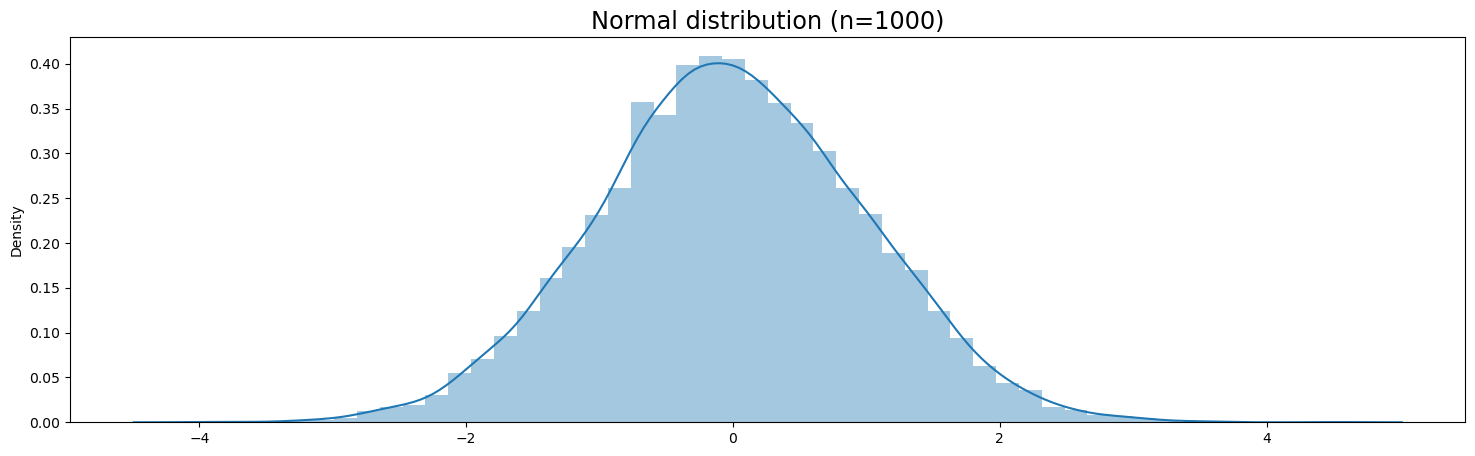

In [10]:
# Normal Distribution as a Bell Curve
plt.figure(figsize=(18,5))
sns.distplot(normal_df)
plt.title('Normal distribution (n=1000)', fontsize='xx-large')
plt.show()

### Binomial Distribution

Phân phối nhị thức (Binomial Distribution) có một số lượng kết quả đếm được và do đó là rời rạc.

Phân phối nhị thức phải đáp ứng ba tiêu chí sau:

1. Số quan sát hoặc thử nghiệm là cố định. Nói cách khác, bạn chỉ có thể tính xác suất của một sự kiện xảy ra nếu bạn thực hiện nó một số lần cố định.
2. Mỗi quan sát hoặc thử nghiệm là độc lập. Nói cách khác, không có thử nghiệm nào ảnh hưởng đến xác suất của thử nghiệm tiếp theo.
3. Xác suất thành công là hoàn toàn giống nhau từ một thử nghiệm đến thử nghiệm khác.

Một giải thích trực quan về phân phối nhị thức là tung một đồng xu 10 lần. Nếu chúng ta tung một đồng xu, khả năng nhận được mặt trước (p) là 0.50. Bây giờ chúng ta tung đồng xu 10 lần và đếm xem có bao nhiêu lần ra mặt trước. Trong hầu hết các tình huống, chúng ta sẽ được mặt trước 5 lần, nhưng cũng có khả năng chúng ta được mặt trước 9 lần. Hàm khối xác suất (PMF) của phân phối nhị thức sẽ cho chúng ta các xác suất này nếu chúng ta nói N = 10 và p = 0.5. Chúng ta nói rằng x cho mặt trước là 1 và 0 cho mặt sau.

PMF:

![](http://reliabilityace.com/formulas/binomial-pmf.png)

CDF:

![](http://reliabilityace.com/formulas/binomial-cpf.png)


**Phân phối Bernoulli** là một trường hợp đặc biệt của phân phối nhị thức.

Tất cả các giá trị trong phân phối Bernoulli đều là 0 hoặc 1.

Ví dụ, nếu chúng ta tung một đồng xu, rơi vào mặt trước 60% thời gian, chúng ta có thể mô tả phân phối Bernoulli như sau:


p (mặt trước) = 0.6

1 - p (mặt sai) = 0.4

Mặt trước = 1

Mặt sau = 0

Một cách chính thức, chúng ta có thể mô tả một phân phối Bernoulli bằng Hàm Phân phối xác suất (PMF) sau đây:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/a9207475ab305d280d2958f5c259f996415548e9)


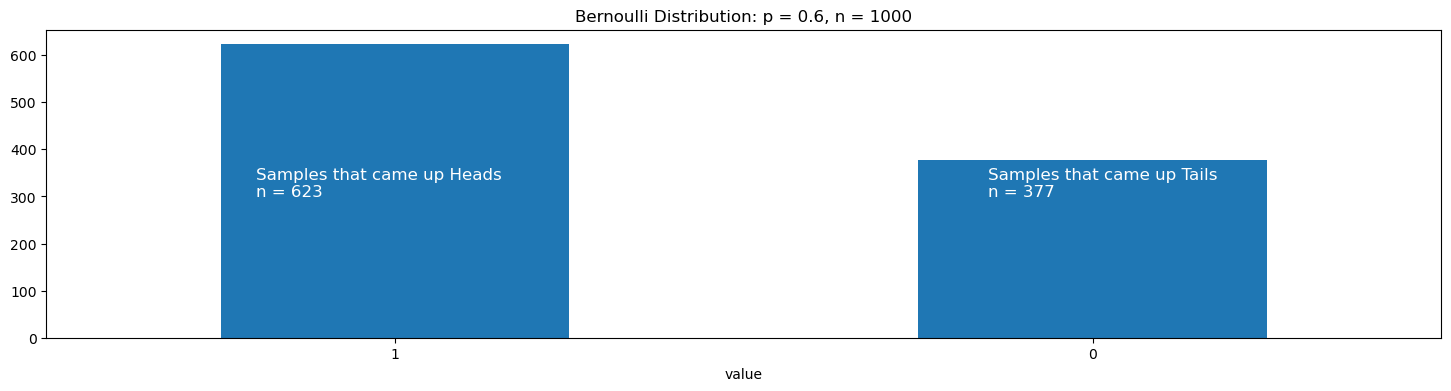

In [11]:
# Change of heads (outcome 1)
p = 0.6

# Create Bernoulli samples
bern_dist = bernoulli.rvs(p, size=1000)
bern_df = pd.DataFrame({'value' : bern_dist})
bern_values = bern_df['value'].value_counts()

# Plot Distribution
plt.figure(figsize=(18,4))
bern_values.plot(kind='bar', rot=0)
plt.annotate(xy=(0.85,300), 
             text='Samples that came up Tails\nn = {}'.format(bern_values[0]), 
             fontsize='large', 
             color='white')
plt.annotate(xy=(-0.2,300), 
             text='Samples that came up Heads\nn = {}'.format(bern_values[1]), 
             fontsize='large', 
             color='white')
plt.title('Bernoulli Distribution: p = 0.6, n = 1000')
plt.show()

### Poisson Distribution

Phân phối Poisson là một phân phối rời rạc và thường được sử dụng để mô hình hóa số lần một sự kiện xảy ra trong một khoảng thời gian hoặc không gian cụ thể.

Nó có một giá trị lambda, mà bằng với giá trị trung bình của phân phối.

PMF: 

![](https://study.com/cimages/multimages/16/poisson1a.jpg)


CDF: 

![](http://www.jennessent.com/images/cdf_poisson.gif)

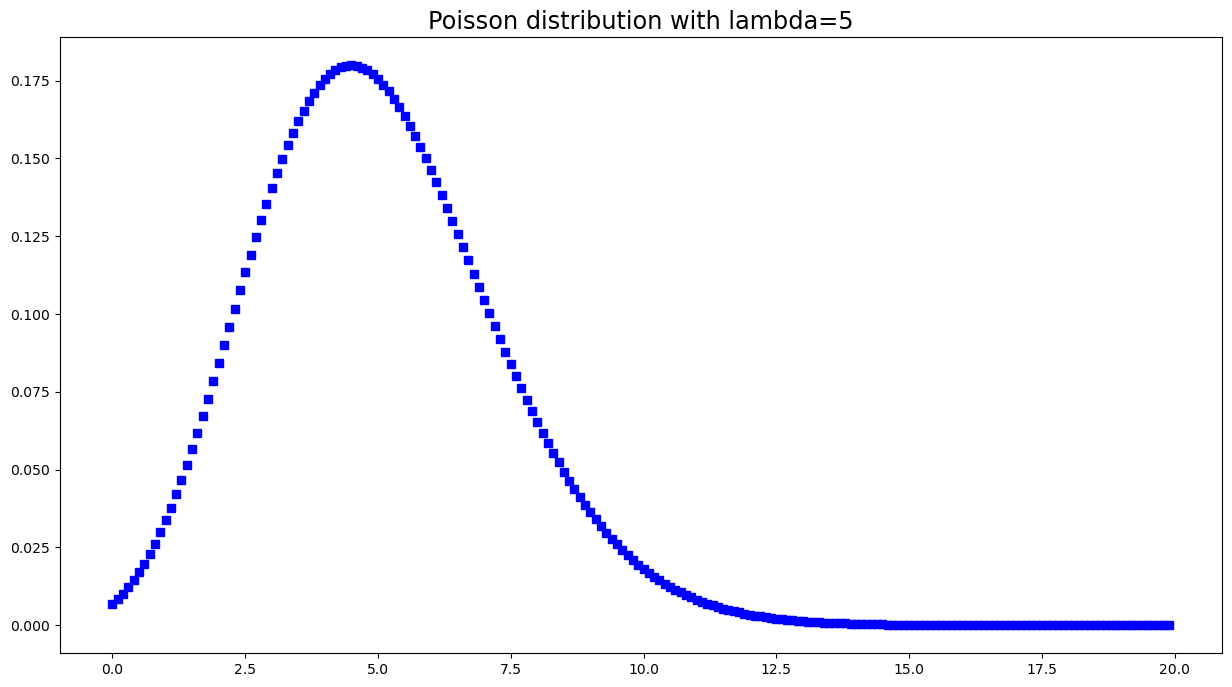

In [12]:
x = np.arange(0, 20, 0.1)
y = np.exp(-5)*np.power(5, x)/factorial(x)

plt.figure(figsize=(15,8))
plt.title('Poisson distribution with lambda=5', fontsize='xx-large')
plt.plot(x, y, 'bs')
plt.show()

### Log-Normal Distribution

Phân phối log-normal là một phân phối liên tục. Đặc điểm chính của một phân phối log-normal là logarithm của nó tuân theo phân phối chuẩn. Nó cũng được gọi là phân phối Galton..

PDF: 

![](https://www.mhnederlof.nl/images/lognormaldensity.jpg)

CDF:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/29095d9cbd6539833d549c59149b9fc5bd06339b)

Ở đây, Phi là hàm phân phối tích lũy (CDF) của phân phối chuẩn hoá.

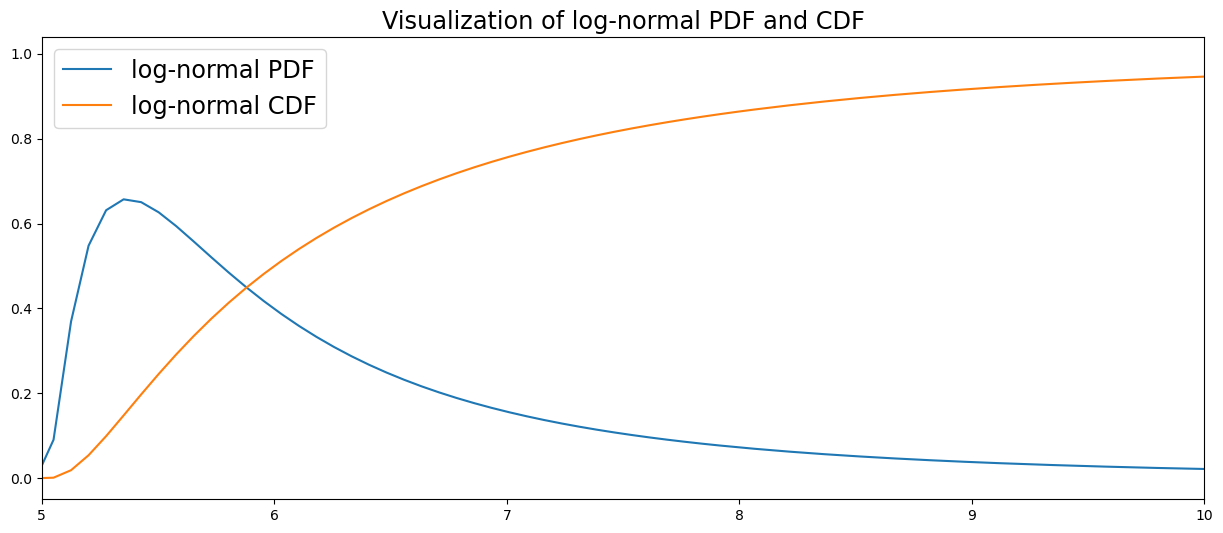

In [13]:
# Specify standard deviation and mean
std = 1
mean = 5

# Create log-normal distribution
dist=lognorm(std,loc=mean)
x=np.linspace(0,15,200)

# Visualize log-normal distribution
plt.figure(figsize=(15,6))
plt.xlim(5, 10)
plt.plot(x,dist.pdf(x), label='log-normal PDF')
plt.plot(x,dist.cdf(x), label='log-normal CDF')
plt.legend(fontsize='xx-large')
plt.title('Visualization of log-normal PDF and CDF', fontsize='xx-large')
plt.show()

## Summary Statistics and Moments <a id="4"></a>

**Mean, Median and Mode** 



![](https://qph.fs.quoracdn.net/main-qimg-29a4925034e075f16e1c743a4b3dda8b)

### Moments

Một khoảnh là một phép đo định lượng cho biết điều gì đó về hình dạng của phân phối. Có khoảnh trung tâm và khoảnh không trung tâm. Phần này tập trung vào khoảnh trung tâm.

Khoảnh trung tâm thứ 0 là tổng xác suất và luôn bằng 1.

Khoảnh thứ 1 là giá trị trung bình (kỳ vọng).

Khoảnh trung tâm thứ 2 là phương sai.

**Phương sai (Variance)** = Trung bình bình phương khoảng cách từ giá trị trung bình. Phương sai thú vị trong mặt toán, nhưng độ lệch chuẩn thường là một phép đo tốt hơn nhiều để đo độ phân tán của phân phối.

![](http://www.visualmining.com/wp-content/uploads/2013/02/analytics_formula_variance.png)

**Độ lệch chuẩn (Standard Deviation)** = Căn bậc hai của phương sai.

![](http://www.visualmining.com/wp-content/uploads/2013/02/analytics_formula_std_dev.png)

**Skewness** = Một độ đo mô tả sự tương phản giữa đuôi dài và đuôi ngắn. Ví dụ, nếu có nhiều giá trị cao hơn trong phân phối của bạn so với giá trị thấp, thì phân phối của bạn có sự "nghiêng" về phía các giá trị cao.

![](http://www.visualmining.com/wp-content/uploads/2013/02/analytics_formula_skewness.png)

**Kurtosis** = là một độ đo của đuôi của phân phối, cho biết có bao nhiêu giá trị ở xa hơn trung tâm so với một phân phối chuẩn. 

![](http://www.visualmining.com/wp-content/uploads/2013/02/analytics_formula_kurtosis.png)



In [14]:
# Summary
print('Summary Statistics for a normal distribution: ')
# Median
medi = median(normal_dist)
print('Median: ', medi)
print(normal_df.describe())

# Standard Deviation
std = sqrt(np.var(normal_dist))

print('The first four calculated moments of a normal distribution: ')
# Mean
mean = normal_dist.mean()
print('Mean: ', mean)

# Variance
var = np.var(normal_dist)
print('Variance: ', var)

# Return unbiased skew normalized by N-1
skew = normal_df['value'].skew()
print('Skewness: ', skew)

# Return unbiased kurtosis over requested axis using Fisher’s definition of kurtosis 
# (kurtosis of normal == 0.0) normalized by N-1
kurt = normal_df['value'].kurtosis()
print('Kurtosis: ', kurt)

Summary Statistics for a normal distribution: 
Median:  -0.024298698957211012


,value
count,10000.000000
mean,-0.012126
std,0.999927
min,-4.016361
25%,-0.677714
50%,-0.024299
75%,0.657819
max,4.538764


The first four calculated moments of a normal distribution: 
Mean:  -0.012126036097218228
Variance:  0.9997534770180435
Skewness:  0.022579073084188044
Kurtosis:  0.019832251209974228


## Bias, MSE and SE <a id="5"></a>

Bias (Thiên vị) là một độ đo cho biết mức độ lệch giữa trung bình của mẫu so với trung bình của quần thể. Trung bình của mẫu còn được gọi là Giá trị kỳ vọng.

Công thức tính Bias:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/82a9c6501a54260ed0edd2f03923719b9f2db906)

Công thức cho Giá trị kỳ vọng (EV) cho thấy rằng thiên vị cũng có thể được công thức hóa như sau: Bias bằng giá trị kỳ vọng trừ đi trung bình của quần thể:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/12828b1f927b39d2fa9d75f82c02b91209182911)

In [15]:
# Take sample
normal_df_sample = normal_df.sample(100)

# Calculate Expected Value (EV), population mean and bias
ev = normal_df_sample.mean()[0]
pop_mean = normal_df.mean()[0]
bias = ev - pop_mean

In [16]:
print('Sample mean (Expected Value): ', ev)
print('Population mean: ', pop_mean)
print('Bias: ', bias)

Sample mean (Expected Value):  -0.056958300425754615
Population mean:  -0.012126036097218228
Bias:  -0.04483226432853639


**MSE (Mean Squared Error)** là một công thức để đo lường mức độ sai khác của các ước tính so với phân phối thực tế. Điều này có thể rất hữu ích trong việc đánh giá các mô hình hồi quy chẳng hạn. 


![](https://i.stack.imgur.com/iSWyZ.png)


**RMSE (Root Mean Squared Error)** là căn bậc hai của MSE.


![](http://file.scirp.org/Html/htmlimages/5-2601289x/fcdba7fc-a40e-4019-9e95-aca3dc2db149.png)



In [17]:
from math import sqrt

Y = 100 # Actual Value
YH = 94 # Predicted Value

# MSE Formula 
def MSE(Y, YH):
     return np.square(YH - Y).mean()

# RMSE formula
def RMSE(Y, YH):
    return sqrt(np.square(YH - Y).mean())


print('MSE: ', MSE(Y, YH))

print('RMSE: ', RMSE(Y, YH))

MSE:  36.0
RMSE:  6.0


The **Standard Error (SE)** measures how spread the distribution is from the sample mean.

![](http://desktopia.net/p/2018/07/standard-deviation-biology-for-life-in-standard-error-of-the-mean-formula.gif)

The formula can also be defined as the standard deviation divided by the square root of the number of samples.

![](https://toptipbio.com/wp-content/uploads/2017/07/Standard-error-formula.jpg)

In [18]:
# Standard Error (SE)
uni_sample = uniform_dist.sample(100)
norm_sample = normal_dist.sample(100)

print('Standard Error of uniform sample: ', sem(uni_sample))
print('Standard Error of normal sample: ', sem(norm_sample))

# The random samples from the normal distribution should have a higher standard error

Standard Error of uniform sample:  0.030200258889904942
Standard Error of normal sample:  0.1053202024204066


## Sampling methods <a id="6"></a>

**Mẫu không đại diện:**

Chọn mẫu tiện lợi (Convenience Sampling) = Chọn mẫu dễ dàng tiếp cận như trên kệ hoặc người dễ tiếp cận.

Chọn mẫu tình cờ (Haphazard Sampling) = Chọn mẫu mà không suy nghĩ. Điều này thường tạo ra ấn tượng rằng bạn đang chọn mẫu một cách ngẫu nhiên.

Chọn mẫu có mục đích (Purposive Sampling) = Chọn mẫu cho một mục tiêu cụ thể. Một ví dụ là tập trung vào các trường hợp cực đoan. Điều này có thể hữu ích nhưng bị giới hạn vì nó không cho phép bạn đưa ra tuyên bố về toàn bộ quần thể.

**Mẫu đại diện:**

Chọn mẫu ngẫu nhiên đơn giản (Simple Random Sampling) = Chọn mẫu ngẫu nhiên.

Chọn mẫu có hệ thống (Systematic Sampling) = Chọn mẫu với một khoảng cách cố định. Ví dụ, mỗi mẫu thứ 10 (0, 10, 20, v.v.).

Chọn mẫu theo nhóm (Stratified Sampling) = Chọn cùng một lượng mẫu từ các nhóm (strata) khác nhau trong quần thể.

Chọn mẫu theo cụm  (Cluster Sampling) = Chia quần thể thành các nhóm (cụm) và chọn mẫu từ các nhóm đó.

In [20]:
# Note that we take very small samples just to illustrate the different sampling methods

print('---Non-Representative samples:---\n')
# Convenience samples
con_samples = normal_dist[0:5]
print('Convenience samples:\n\n{}\n'.format(con_samples))

# Haphazard samples (Picking out some numbers)
hap_samples = [normal_dist[12], normal_dist[55], normal_dist[582], normal_dist[821], normal_dist[999]]
print('Haphazard samples:\n\n{}\n'.format(hap_samples))

# Purposive samples (Pick samples for a specific purpose)
# In this example we pick the 5 highest values in our distribution
purp_samples = normal_dist.nlargest(n=5)
print('Purposive samples:\n\n{}\n'.format(purp_samples))

print('---Representative samples:---\n')

# Simple (pseudo)random sample
rand_samples = normal_dist.sample(5)
print('Random samples:\n\n{}\n'.format(rand_samples))

# Systematic sample (Every 2000th value)
sys_samples = normal_dist[normal_dist.index % 2000 == 0]
print('Systematic samples:\n\n{}\n'.format(sys_samples))

# Stratified Sampling
# We will get 1 person from every city in the dataset
# We have 8 cities so that makes a total of 8 samples
df = pd.read_csv('L12_datasets/toy_dataset.csv')

strat_samples = []

for city in df['City'].unique():
    samp = df[df['City'] == city].sample(1)
    strat_samples.append(samp['Income'].item())
    
print('Stratified samples:\n\n{}\n'.format(strat_samples))

# Cluster Sampling
# Make random clusters of ten people (Here with replacement)
c1 = normal_dist.sample(10)
c2 = normal_dist.sample(10)
c3 = normal_dist.sample(10)
c4 = normal_dist.sample(10)
c5 = normal_dist.sample(10)

# Take sample from every cluster (with replacement)
clusters = [c1,c2,c3,c4,c5]
cluster_samples = []
for c in clusters:
    clus_samp = c.sample(1)
    cluster_samples.extend(clus_samp)
print('Cluster samples:\n\n{}'.format(cluster_samples))    


---Non-Representative samples:---

Convenience samples:

0   -0.727028
1   -0.592258
2   -1.401216
3    0.988591
4    0.077900
dtype: float64

Haphazard samples:

[0.538357388565413, -0.2858537543929468, 0.8873580277676636, -1.5733778850834552, 0.5157006940846643]

Purposive samples:

4733    4.538764
653     3.614361
3199    3.548591
5297    3.502774
8069    3.331826
dtype: float64

---Representative samples:---

Random samples:

2636   -0.328341
8344    0.950312
5165    0.654917
3295    1.437059
5046   -0.391351
dtype: float64

Systematic samples:

0      -0.727028
2000    0.483008
4000   -0.539284
6000    0.812615
8000    0.327456
dtype: float64

Stratified samples:

[59640.0, 90699.0, 69620.0, 144459.0, 93841.0, 53202.0, 85329.0, 84182.0]

Cluster samples:

[0.3007897968183413, 0.5546167904130631, -1.2830059812309815, -1.196492787058934, 0.5325998147958547]


## Covariance <a id="7"></a>

Covariance (Hiệp Phương sai) là một đo lường cho việc hai biến ngẫu nhiên biến thiên cùng nhau. Phương sai tương tự với hiệp biến trong việc phương sai cho bạn biết mức độ biến thiên của một biến. Covariance cho bạn biết cách hai biến biến thiên cùng nhau.

Nếu hai biến là độc lập, thì hiệp biến của chúng sẽ bằng 0. Tuy nhiên, một hiệp biến bằng 0 không ngụ ý rằng các biến là độc lập.

In [21]:
# Covariance between Age and Income
print('Covariance between Age and Income: ')

df[['Age', 'Income']].cov()

Covariance between Age and Income: 


,Age,Income
Age,133.922426,-3.811863e+02
Income,-381.186341,6.244752e+08


## Correlation <a id="8"></a>

Tương quan (Correlation) là một phiên bản chuẩn hóa của hiện tượng biến đổi chung. Ở đây, nó trở nên rõ hơn rằng Tuổi và Thu nhập không có mối tương quan mạnh trong tập dữ liệu của chúng ta.


Công thức cho hệ số tương quan Pearson bao gồm hiệp phương sai giữa hai biến ngẫu nhiên chia cho độ lệch chuẩn của biến ngẫu nhiên thứ nhất nhân với độ lệch chuẩn của biến ngẫu nhiên thứ hai.

Công thức cho hệ số tương quan Pearson:

![](http://sherrytowers.com/wp-content/uploads/2013/09/correlation_xy-300x97.jpg)

In [22]:
# Correlation between two normal distributions
# Using Pearson's correlation
print('Pearson: ')
print(df[['Age', 'Income']].corr(method='pearson'))

Pearson: 
             Age    Income
Age     1.000000 -0.001318
Income -0.001318  1.000000


Một phương pháp khác để tính hệ số tương quan là 'Spearman's Rho'. Công thức có vẻ khác biệt nhưng sẽ cho kết quả tương tự như phương pháp của Pearson. Trong ví dụ này, chúng ta thấy rằng gần như không có sự khác biệt, nhưng điều này một phần là do rõ ràng rằng cột Tuổi và Thu nhập trong tập dữ liệu của chúng ta không có mối tương quan.

Công thức cho Spearman's Rho:

![](http://s3.amazonaws.com/hm_120408/fa/3d86/yhf5/9dwq/4m6e2kcav/original.jpg?1447778688)

In [23]:
# Using Spearman's rho correlation
print('Spearman: ')
df[['Age', 'Income']].corr(method='spearman')

Spearman: 


,Age,Income
Age,1.000000,-0.001452
Income,-0.001452,1.000000


## Hypothesis testing <a id="11"></a>

Kiểm định giả thuyết là một hình thức của thống kê suy luận cho phép chúng ta rút ra kết luận về toàn bộ quần thể dựa trên một mẫu đại diện.


Chúng ta thiết lập hai giả thuyết, H0 (giả thuyết không) và Ha (giả thuyết thay thế).


Chúng ta có thể đưa ra bốn quyết định khác nhau trong kiểm định giả thuyết:

1. Từ chối H0 và H0 không đúng (không có lỗi)
2. Không từ chối H0 và H0 đúng (không có lỗi)
3. Từ chối H0 và H0 đúng (Lỗi loại 1)
4. Không từ chối H0 và H0 không đúng (Lỗi loại 2)

Lỗi loại 1 còn được gọi là lỗi Alpha.
Lỗi loại 2 còn được gọi là lỗi Beta.

![](https://qph.fs.quoracdn.net/main-qimg-84121cf5638cbb5919999b2a8d928c91)

![](https://i.stack.imgur.com/x1GQ1.png)

### P-Value

P-value (giá trị p) là xác suất tìm thấy kết quả bằng hoặc cực kỳ tương tự khi giả thuyết không (H0) đúng. Nói cách khác, giá trị p thấp đồng nghĩa với việc có bằng chứng mạnh mẽ để từ chối giả thuyết H0.

Nếu giá trị p thấp hơn 5% (p < 0.05). Thường chúng ta sẽ từ chối H0 và chấp nhận rằng Ha đúng. Chúng ta nói rằng p < 0.05 có ý nghĩa thống kê, bởi vì có ít hơn 5% cơ hội rằng chúng ta sai khi từ chối giả thuyết H0.

Một cách để tính giá trị p là thông qua một kiểm định T. Chúng ta có thể sử dụng hàm  [Scipy's ttest_ind function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) để tính kiểm định t cho trung bình của hai mẫu độc lập các điểm số. Trong ví dụ này, chúng ta tính toán thống kê t và giá trị p của hai mẫu ngẫu nhiên 10 lần.

Chúng ta thấy giá trị p đôi khi rất thấp, nhưng điều này không có nghĩa rằng hai mẫu ngẫu nhiên này có tương quan. Đây là lý do tại sao bạn phải cẩn thận khi dựa quá nhiều vào giá trị p. Nếu bạn lặp lại một thí nghiệm nhiều lần, bạn có thể mắc phải hiện tượng ảo tưởng rằng có tương quan trong khi thực chất chỉ là ngẫu nhiên.






In [24]:
# Perform t-test and compute p value of two random samples
print('T-statistics and p-values of two random samples.')
for _ in range(10):
    rand_sample1 = np.random.random_sample(10)
    rand_sample2 = np.random.random_sample(10)
    print(stats.ttest_ind(rand_sample1, rand_sample2))

T-statistics and p-values of two random samples.
TtestResult(statistic=-0.666503394959508, pvalue=0.513542388270261, df=18.0)
TtestResult(statistic=0.7894883760708197, pvalue=0.44010310167217526, df=18.0)
TtestResult(statistic=-1.6582354737870577, pvalue=0.11459412330503073, df=18.0)
TtestResult(statistic=-0.5095828143587255, pvalue=0.6165345465361483, df=18.0)
TtestResult(statistic=0.5701046940697747, pvalue=0.5756542886936734, df=18.0)
TtestResult(statistic=0.49890008600113495, pvalue=0.623891883898835, df=18.0)
TtestResult(statistic=-1.0559451497220949, pvalue=0.30496064327562855, df=18.0)
TtestResult(statistic=-0.3298686167844484, pvalue=0.7453071899557774, df=18.0)
TtestResult(statistic=1.4992962350542747, pvalue=0.15113142153376122, df=18.0)
TtestResult(statistic=0.484825256814402, pvalue=0.6336478058673141, df=18.0)


## Outliers <a id="12"></a>

Một ngoại lệ (outlier) là một quan sát mà lệch khỏi các quan sát khác. Thường thì một ngoại lệ nổi bật và có thể là một lỗi.


Ngoại lệ có thể làm ảnh hưởng tới các mô hình thống kê của bạn. Tuy nhiên, ngoại lệ chỉ nên bị loại bỏ khi bạn đã xác định được lý do tốt để loại bỏ ngoại lệ.


Đôi khi, ngoại lệ là chủ đề quan trọng của sự quan tâm. Điều này ví dụ như trong việc phát hiện gian lận. Có nhiều phương pháp phát hiện ngoại lệ, nhưng ở đây chúng ta sẽ thảo luận về kiểm tra Grubbs và phương pháp Tukey. Cả hai kiểm tra đều giả định rằng dữ liệu tuân theo phân phối chuẩn.


### Grubbs Test

Trong kiểm tra Grubbs, giả thuyết không có (null hypothesis) là rằng không có quan sát nào là ngoại lệ, trong khi giả thuyết thay thế (alternative hypothesis) là có một quan sát là ngoại lệ. Do đó, kiểm tra Grubbs chỉ tìm kiếm một quan sát ngoại lệ.

Công thức của Grubbs test:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/bafc310f1dbca658728c73256fed19b6a7f11130)

Ở đây, Y_hat là giá trị trung bình mẫu và s là độ lệch chuẩn mẫu. Thống số kiểm tra Grubbs là độ lệch tuyệt đối lớn nhất so với giá trị trung bình mẫu, tính bằng đơn vị độ lệch chuẩn mẫu.


[Source](https://en.wikipedia.org/wiki/Grubbs%27_test_for_outliers)

### Tukey's method


Tukey đề xuất rằng một quan sát được xem là ngoại lệ khi nó thấp hơn 1.5 lần phạm vi giữa tứ phân vị dưới của phạm vi giữa tứ phân vị đầu tiên hoặc cao hơn 1.5 lần phạm vi giữa tứ phân vị trên của phạm vi giữa tứ phân vị thứ ba. Điều này có vẻ phức tạp, nhưng nếu bạn xem nó qua hình ảnh, bạn sẽ thấy nó dễ hiểu.

Đối với phân phối chuẩn, tiêu chí của Tukey cho các quan sát ngoại lệ không thể xảy ra nếu không có quan sát ngoại lệ, nhưng việc sử dụng tiêu chí của Tukey cho các phân phối khác nên được xem xét cẩn thận.

Công thức của Tukey's method:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/2a103bbd9233d9f8f711a7c76dfeb9694446f860)

Ya là giá trị lớn hơn trong hai giá trị trung bình đang được so sánh. SE là sai số tiêu chuẩn của tổng của các giá trị trung bình.


[Source](https://en.wikipedia.org/wiki/Tukey%27s_range_test)

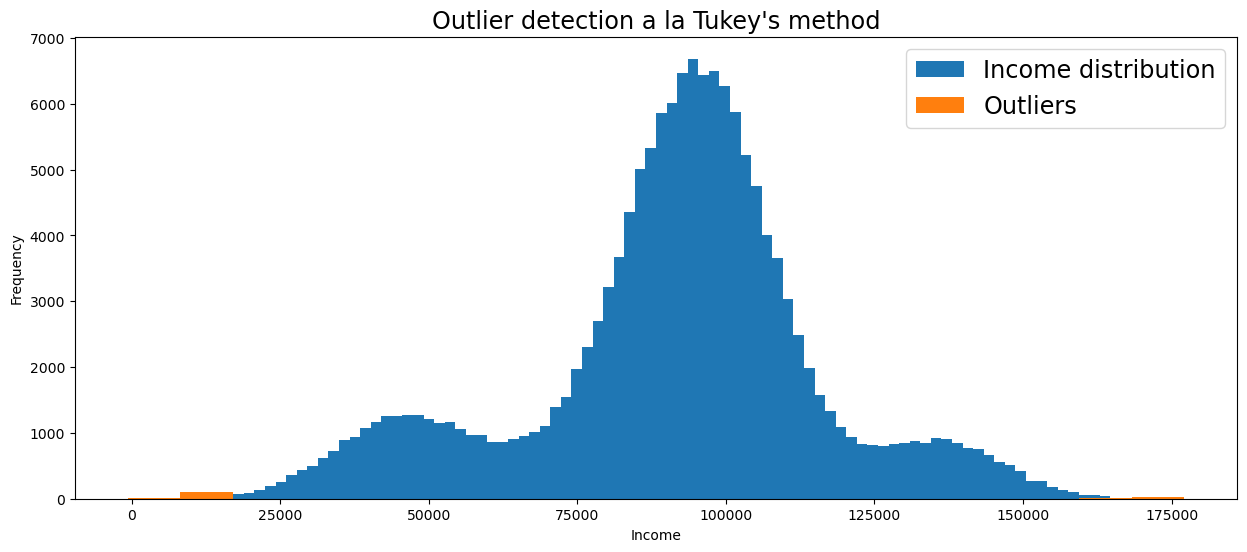

In [25]:
# Detect outliers on the 'Income' column of the Toy Dataset

# Function for detecting outliers a la Tukey's method using z-scores
def tukey_outliers(data) -> list:
    # For more information on calculating the threshold check out:
    # https://medium.com/datadriveninvestor/finding-outliers-in-dataset-using-python-efc3fce6ce32
    threshold = 3
    
    mean = np.mean(data)
    std = np.std(data)
    
    # Spot and collect outliers
    outliers = []
    for i in data:
        z_score = (i - mean) / std
        if abs(z_score) > threshold:
            outliers.append(i)
    return outliers

# Get outliers
income_outliers = tukey_outliers(df['Income'])

# Visualize distribution and outliers
plt.figure(figsize=(15,6))
df['Income'].plot(kind='hist', bins=100, label='Income distribution')
plt.hist(income_outliers, bins=20, label='Outliers')
plt.title("Outlier detection a la Tukey's method", fontsize='xx-large')
plt.xlabel('Income')
plt.legend(fontsize='xx-large')

# The end!

## Tham Khảo <a id="16"></a>

https://dataconomy.com/2015/02/introduction-to-bayes-theorem-with-python

https://www.statisticshowto.datasciencecentral.com/discrete-variable/

https://www.statisticshowto.datasciencecentral.com/probability-and-statistics/binomial-theorem/binomial-distribution-formula/

https://www.statisticshowto.datasciencecentral.com/probability-and-statistics/descriptive-statistics/sample-variance/

https://machinelearningmastery.com/a-gentle-introduction-to-the-bootstrap-method

https://machinelearningmastery.com/k-fold-cross-validation/

https://en.wikipedia.org/wiki/Poisson_distribution

https://www.tutorialspoint.com/python/python_p_value.htm

https://towardsdatascience.com/inferential-statistics-series-t-test-using-numpy-2718f8f9bf2f